# Sesión 5. Ejemplo de aprendizaje supervisado: Regresión.

# Caso práctico Mantenimiento Predictivo

### Objetivo:
Desarrollar un modelo que sea capaz de predecir la RUL (Remaining Useful Life), en ciclos, de cada motor según los valores obtenidos mediante sensores.

Un segundo objetivo, podría ser clasificar el motor segun si se encuentra en los "Últimos 15 ciclos" o no. Esto correspondería a un ejercicio de clasificación, por lo que no se desarrollará durante esta clase.

# 1. Importar librerías y datos (FD001)

In [5]:
# load necessary packages and view available data
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import keras
%matplotlib inline
sns.set()
print(os.listdir("Data/mantenimiento"))

['readme.txt', 'RUL_FD001.txt', 'test_FD001.txt', 'train_FD001.txt']


In [6]:
# load data
train= pd.read_csv('Data/mantenimiento/train_FD001.txt', sep=" ", header=None)
test = pd.read_csv('Data/mantenimiento/test_FD001.txt', sep=" ", header=None)
print("train shape: ", train.shape, "test shape: ", test.shape)

train shape:  (20631, 28) test shape:  (13096, 28)


In [7]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


# 2. Limpieza de datos y EDA

In [8]:
# Buscamos NaN
train.isna().sum()

0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         0
9         0
10        0
11        0
12        0
13        0
14        0
15        0
16        0
17        0
18        0
19        0
20        0
21        0
22        0
23        0
24        0
25        0
26    20631
27    20631
dtype: int64

In [9]:
# Eliminamos las dos últimas columnas (son todas NaN)
train.drop(train.columns[[26, 27]], axis=1, inplace=True)
test.drop(test.columns[[26, 27]], axis=1, inplace=True)

In [10]:
# El archivo no contiene nombre de variables. Creamos las etiquetas basándonos en la documentación.
index_columns_names =  ["UnitNumber","Cycle"]
op_settings_columns = ["Op_Setting_"+str(i) for i in range(1,4)]
sensor_columns =["Sensor_"+str(i) for i in range(1,22)]
column_names = index_columns_names + op_settings_columns + sensor_columns
print(column_names)

['UnitNumber', 'Cycle', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3', 'Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_16', 'Sensor_17', 'Sensor_18', 'Sensor_19', 'Sensor_20', 'Sensor_21']


In [11]:
# name columns
train.columns = column_names
test.columns = column_names
train.head()

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### ¿Dispone nuestro dataset de variable objetivo?
En caso negativo, tendremos que calcularla.

**Pregunta:** ¿Como podemos obtener una columna que indique la Remaining Useful Life (RUL)?

In [12]:
# esta sección calcula la vida útil restante (RUL) en notación T-menos para los datos de entrenamiento
# encuentra el último ciclo por número de unidad
max_cycle = train.groupby('UnitNumber')['Cycle'].max().reset_index()
max_cycle.columns = ['UnitNumber', 'MaxOfCycle']
max_cycle

,UnitNumber,MaxOfCycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
...,...,...
95,96,336
96,97,202
97,98,156
98,99,185


In [13]:
# BORRAR
# fusionar el ciclo max de nuevo en el df original
train_merged = train.merge(max_cycle, left_on='UnitNumber', right_on='UnitNumber', how='inner')
train_merged

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,MaxOfCycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,200
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,200
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,200
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,200


In [14]:
# BORRAR
# calcular el RUL para cada fila
Target_RUL = train_merged["MaxOfCycle"] - train_merged["Cycle"]
train_merged["RUL"] = Target_RUL

# eliminar las columnas innecesarias ('MaxOfCycle')
train_RUL = train_merged.drop("MaxOfCycle", axis=1)
train_RUL.head(5)

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [15]:
train_RUL.shape
train_RUL.describe()

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251,68.880990
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000


**Preguntas:**
* ¿Cuantas unidades tenemos?
* ¿Cual es el valor máximo de vida útil (RUL) de este dataset?
* Si nos dijeran que el motor número 18 es una anomalía, como lo eliminariamos del dataset?

In [16]:
# BORRAR
train_RUL['UnitNumber'].nunique()

100

In [17]:
train_RUL['Cycle'].max()

362

In [18]:
train_RUL[train_RUL['UnitNumber'] != 18]

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


# 3. Visualizar los datos

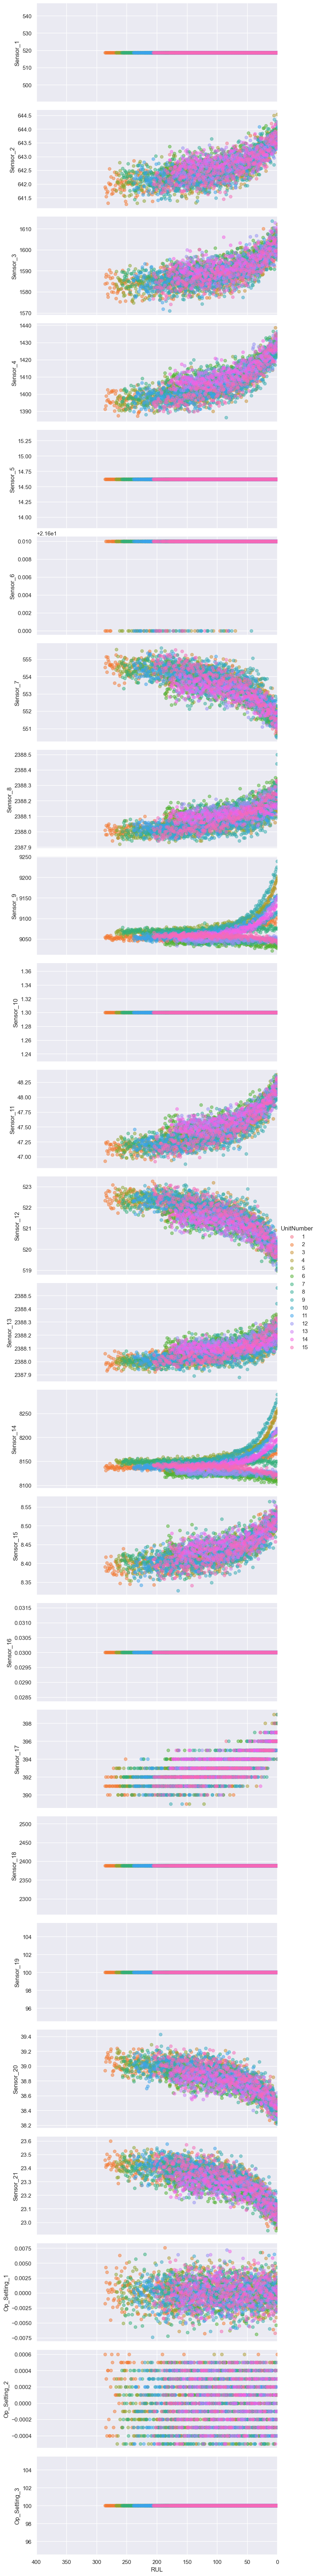

In [19]:
# usamos seaborn para visualizar atributos vs variable objetivo (RUL)
explore = sns.PairGrid(data=train_RUL[train_RUL['UnitNumber']<16] ,
                 x_vars='RUL',
                 y_vars=sensor_columns + op_settings_columns,
                 hue="UnitNumber", height=3, aspect=2.5)
explore = explore.map(plt.scatter, alpha=0.5)
explore = explore.set(xlim=(400,0))
explore = explore.add_legend()

**Pregunta:** ¿Qué podemos observar en los gráficos anteriores?

In [20]:
train_RUL['Op_Setting_3'].describe()

count    20631.0
mean       100.0
std          0.0
min        100.0
25%        100.0
50%        100.0
75%        100.0
max        100.0
Name: Op_Setting_3, dtype: float64

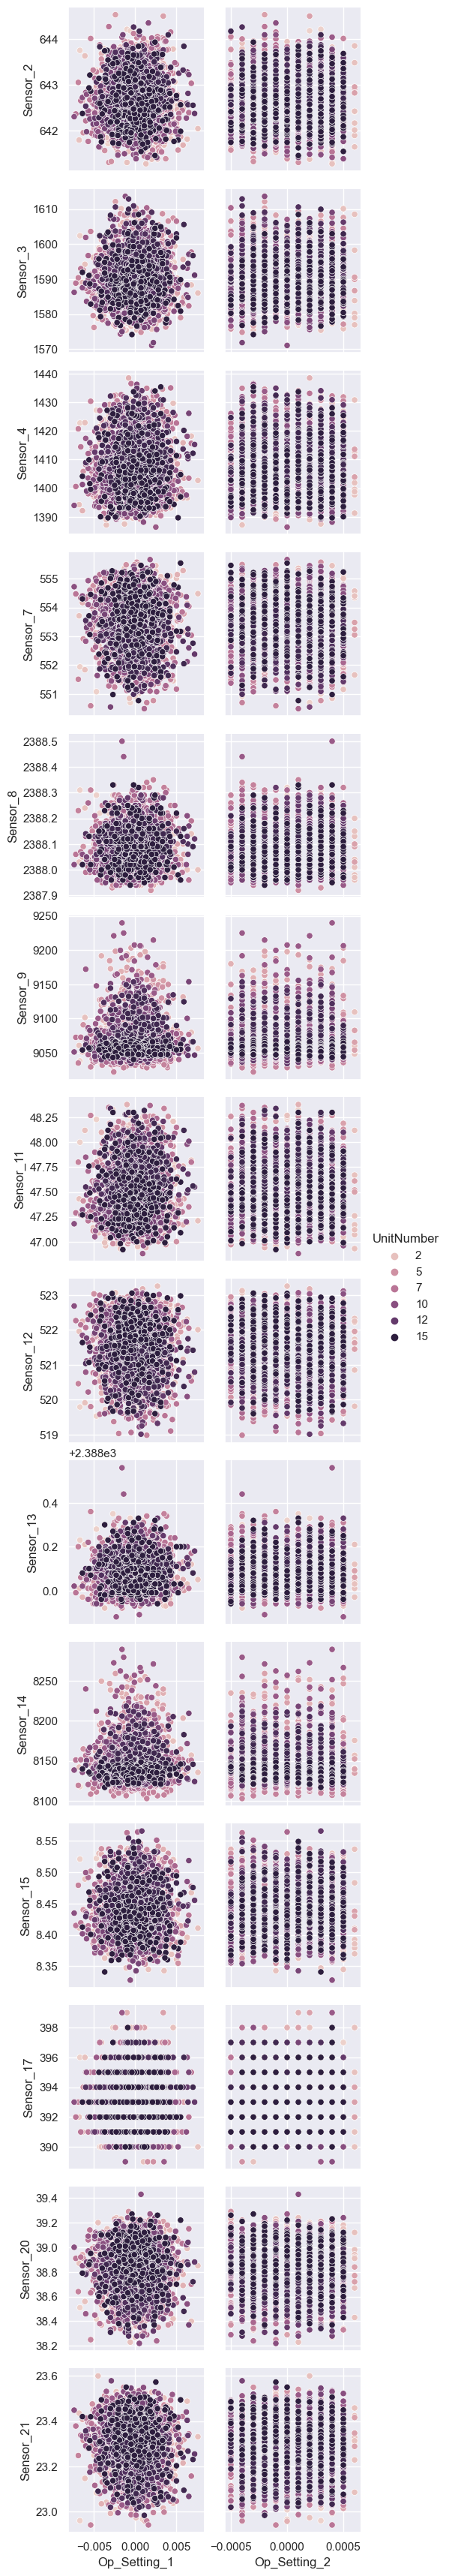

In [21]:
# la configuración operativa 3 es estable, visualicemos las configuraciones operativas 1 y 2 frente a algunos de los sensores más activos
g = sns.pairplot(data=train_RUL[train_RUL['UnitNumber']<16],
                 x_vars=["Op_Setting_1","Op_Setting_2"],
                 y_vars=["Sensor_2", "Sensor_3", "Sensor_4", "Sensor_7", "Sensor_8", "Sensor_9", "Sensor_11", "Sensor_12", "Sensor_13", "Sensor_14", "Sensor_15", "Sensor_17", "Sensor_20", "Sensor_21"],
                 hue="UnitNumber", aspect=1)

### GRÁFICOS QUE NO PUEDEN FALTAR EN UN EDA:
* Histograma de los ciclos máximos (para este caso en concreto)
* Matriz de correlación
* Boxplot/Histograma por característica

Text(0.5, 0, 'Max time cycle')

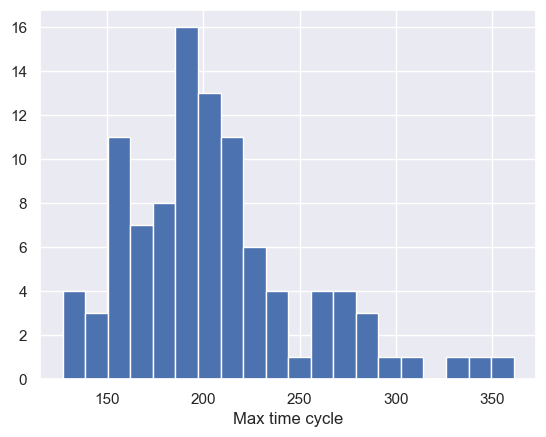

In [22]:
# Distribution of maximum time cycles
plt.hist(train_RUL.groupby('UnitNumber')['RUL'].max(),bins=20)
plt.xlabel('Max time cycle')

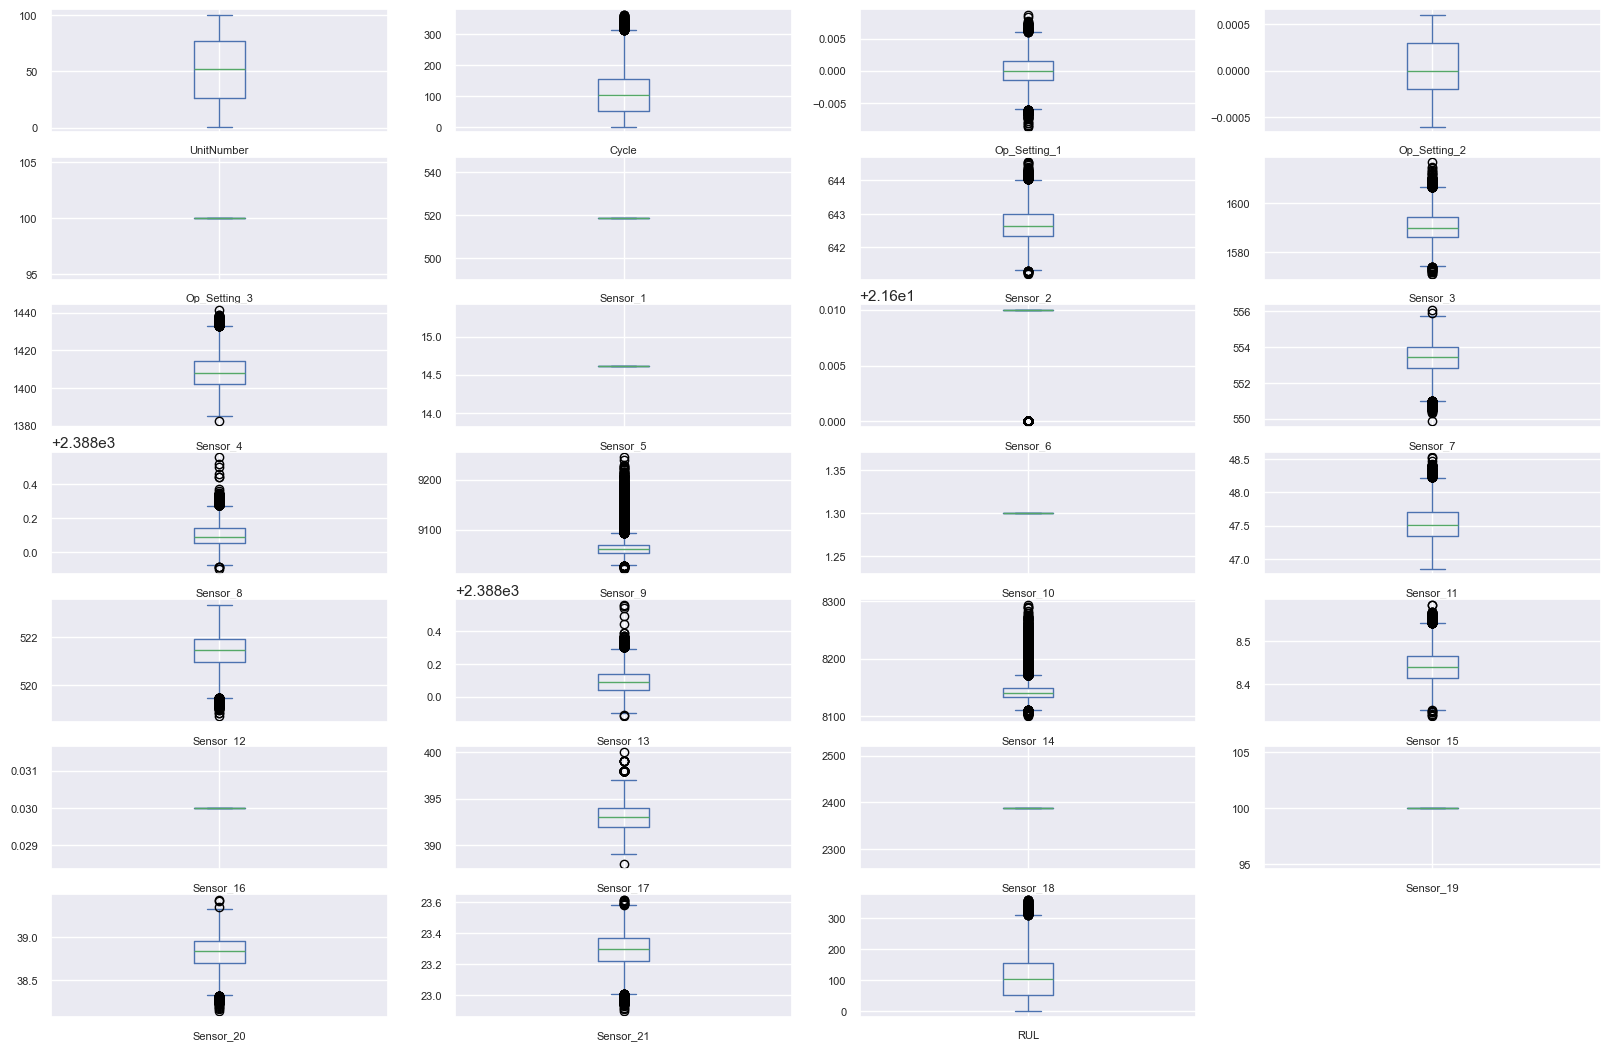

In [23]:
# Obtener el boxplot para cada uno de los atributos.
atributos_boxplot = train_RUL.plot(kind='box', subplots=True, layout=(8, 4), figsize=(20, 15), sharex=False,
                                 sharey=False, fontsize=8)

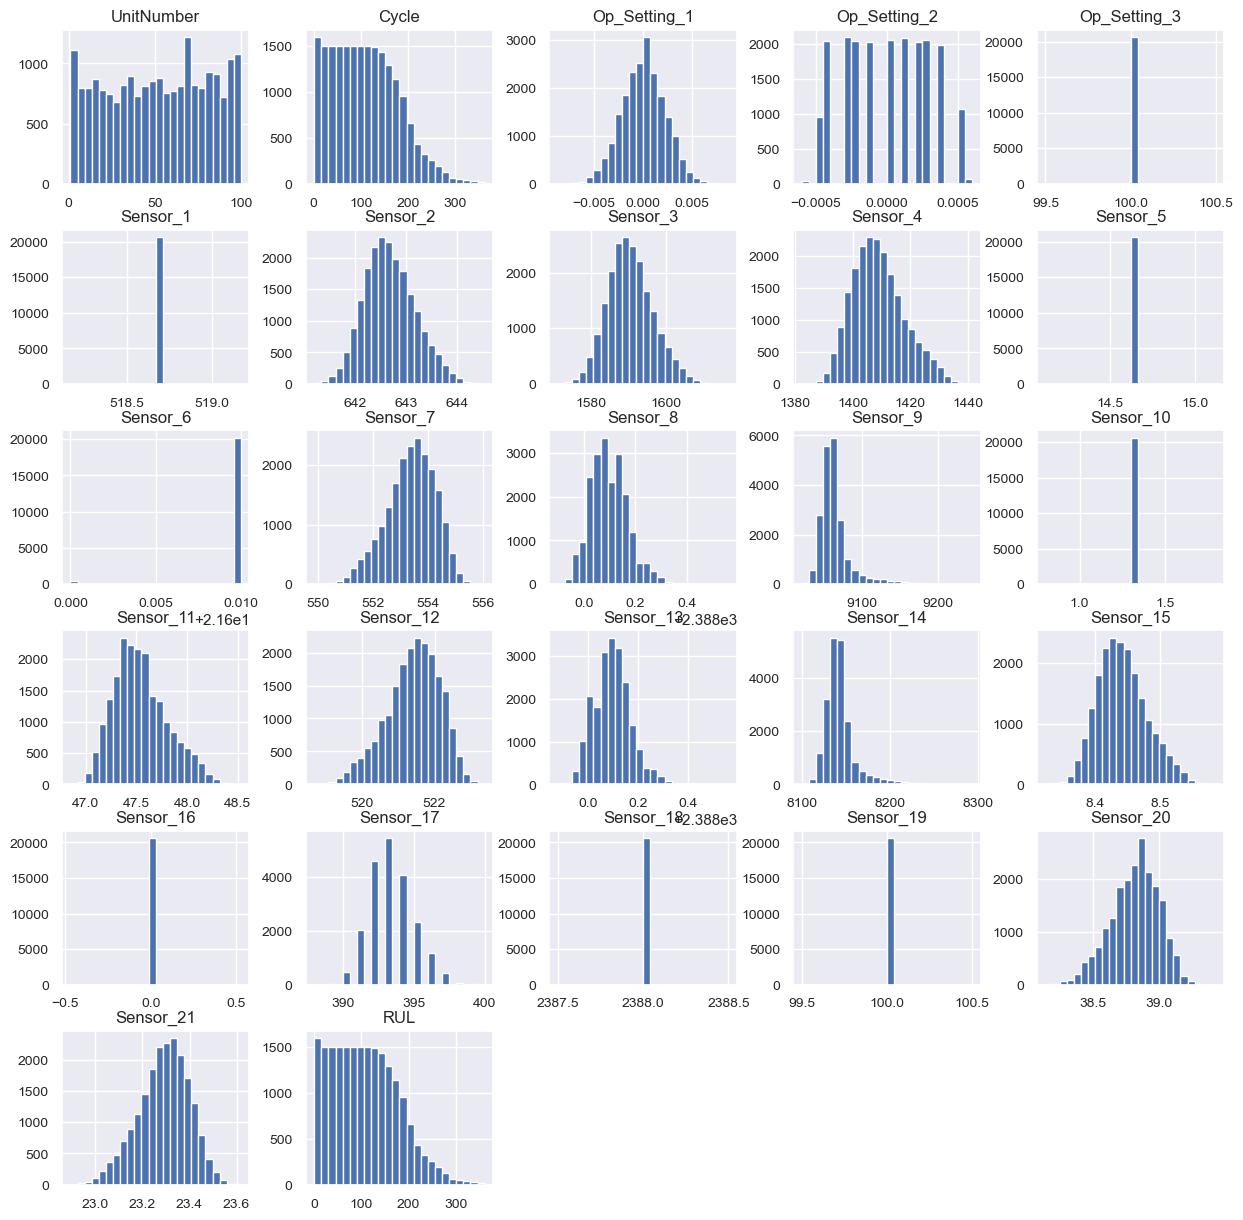

In [24]:
# Obtener los histogramas (distribución de datos) para cada uno de los atributos.
histograma = train_RUL.hist(xlabelsize=10, ylabelsize=10, bins=24, figsize=(15, 15))

C:\Users\marcjv\miniconda3\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

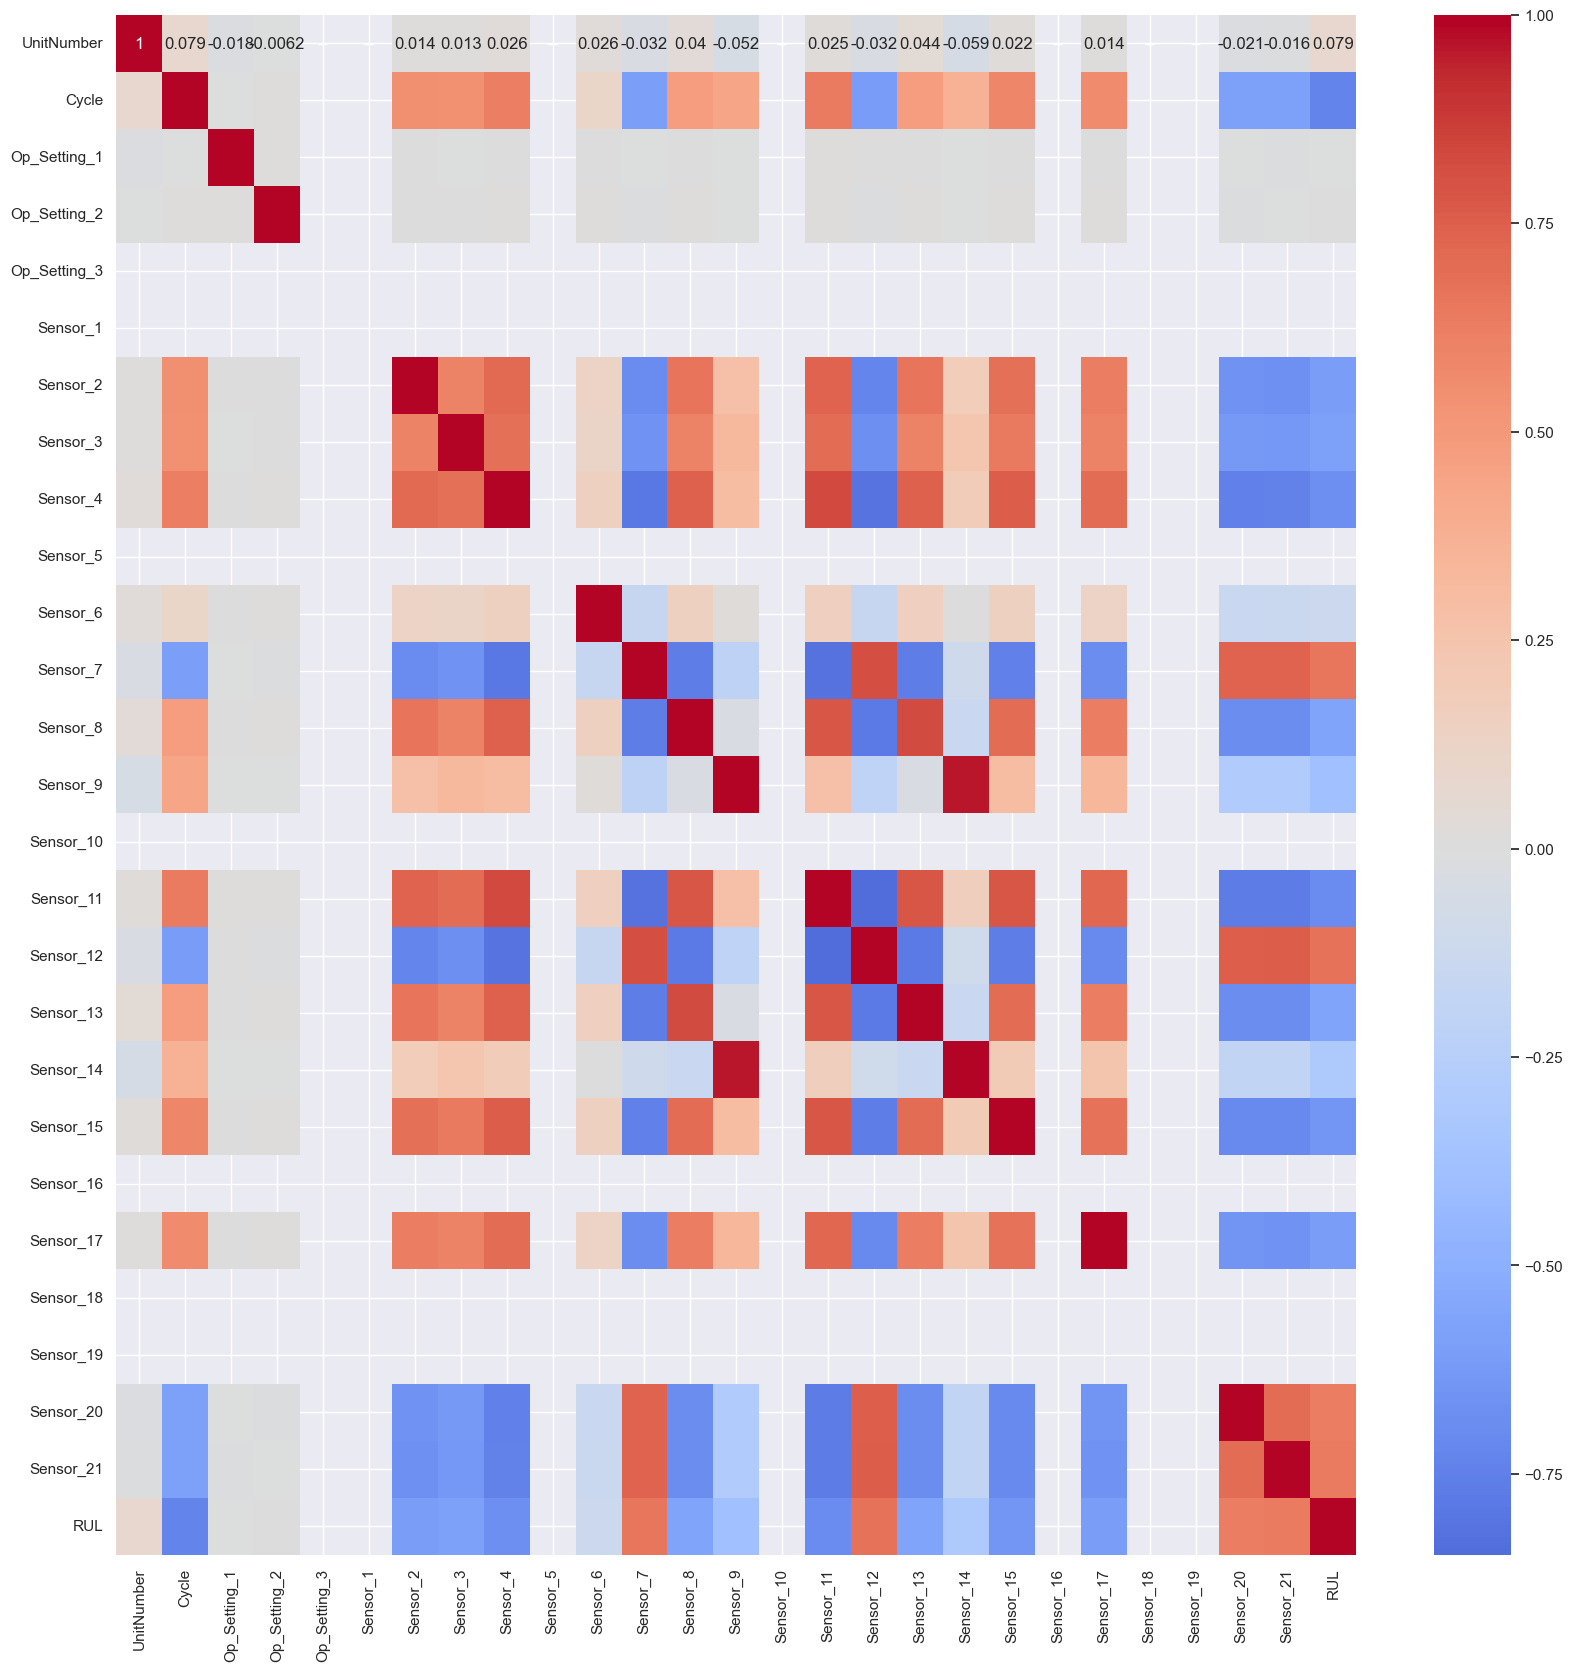

In [25]:
# Correlation matrix
corr = train_RUL.corr()

plt.figure(figsize=(20,20))  
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

**¿Por qué aparecen columnas/filas blancas?**

# 4. Preparación de los datos
Esto incluye, entre otros:
1. Limpieza de datos (en caso de que haya NaN)
2. Feature Engineering (eliminar características que son ruido y crear nuevas, si es necesario)
3. Escalado de los datos

**1. Limpieza de datos**

No hay Nan en los datos de entrada y no se eliminarán valores atípicos en este ejemplo. 

**¿Qué estrategia(s) podríamos usar para limpiar NaN si el dataset tuviera algunos?**

In [26]:
train_RUL.isna().any().any()

False

**2. Feature Engineering**. 
- Eliminamos aquellas columnas que no nos den información relevante (son ruido y lo único que pueden hacer es empeorar nuestro modelo). También miraremos qué importancia tiene cada característica.

**Según el apartado de visualización:** Eliminar S1, S5, S10, S16, S18 y S19

También los settings, ya que hemos visto que no existe ninguna correlación entre ellos y ninguno de los sensores

Antes, pero, vamos a hacer un **ranking de importancia de variables**

Primero eliminamos las siguientes columnas: 'UnitNumber', 'Cycle'

In [27]:
print(train_RUL.shape)
to_drop_1 = ['UnitNumber', 'Cycle'] + op_settings_columns  
train_features = train_RUL.drop(to_drop_1, axis = 1)
print(train_features.shape)

# set up features and target variable 
y = train_features['RUL']
X = train_features.drop(['RUL'], axis = 1)

(20631, 27)
(20631, 22)


In [28]:
# Usamos un random forest simple para determinar algunas de las características más importantes
# Se puede utilizar para seleccionar características
from sklearn.ensemble import RandomForestRegressor
single_rf = RandomForestRegressor()
single_rf.fit(X, y)
y_pred = single_rf.predict(X)

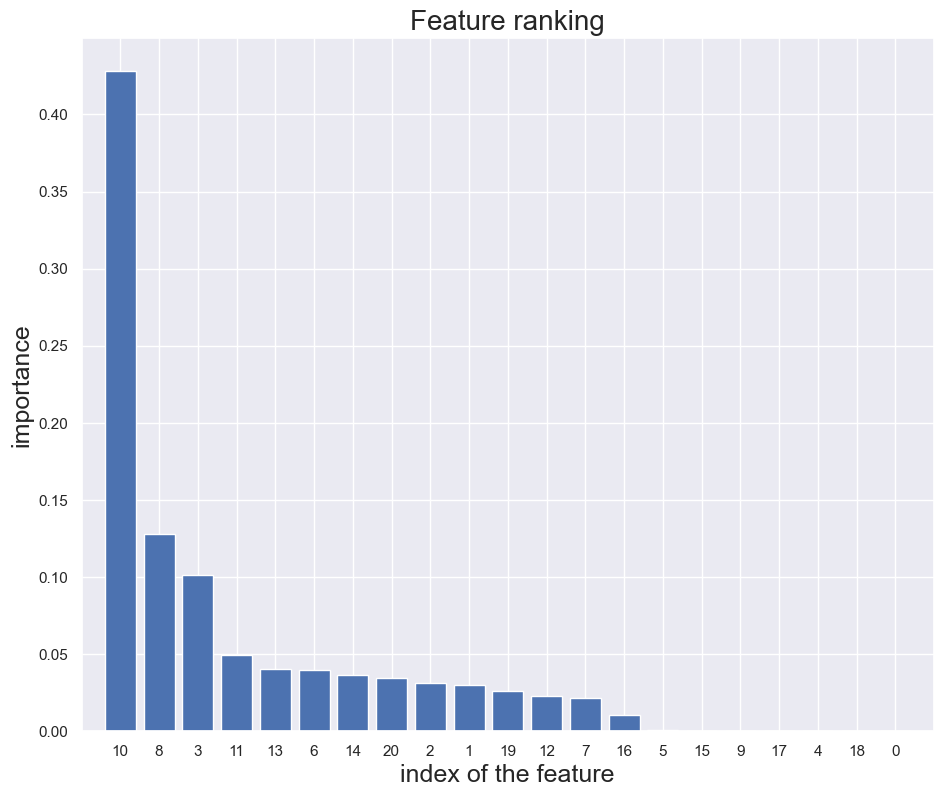

Sensor_11    0.428007
Sensor_9     0.127900
Sensor_4     0.101486
Sensor_12    0.049338
Sensor_14    0.040115
Sensor_7     0.039455
Sensor_15    0.036505
Sensor_21    0.034441
Sensor_3     0.031246
Sensor_2     0.029728
Sensor_20    0.025838
Sensor_13    0.022855
Sensor_8     0.021864
Sensor_17    0.010452
Sensor_6     0.000770
Sensor_10    0.000000
Sensor_5     0.000000
Sensor_16    0.000000
Sensor_18    0.000000
Sensor_19    0.000000
Sensor_1     0.000000
dtype: float64


In [29]:
# Gráfico de la importancia de las características
importances = single_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns    
f, ax = plt.subplots(figsize=(11, 9))
plt.title("Feature ranking", fontsize = 20)
plt.bar(range(X.shape[1]), importances[indices], color="b", align="center")
plt.xticks(range(X.shape[1]), indices) #feature_names, rotation='vertical')
plt.xlim([-1, X.shape[1]])
plt.ylabel("importance", fontsize = 18)
plt.xlabel("index of the feature", fontsize = 18)
plt.show()

# list feature importance
important_features = pd.Series(data=single_rf.feature_importances_,index=X.columns)
important_features.sort_values(ascending=False,inplace=True)
print(important_features.head(22))

* Eliminar Variables con poca importancia.

In [30]:
# based on the graphs as well as random forest feature importance, I will exclude sensors without much valuable information
print(train_features.shape)
to_drop_2 = ["Sensor_"+str(i) for i in [17, 6, 10, 5, 16, 18, 19, 1]]
train_final = train_features.drop(to_drop_2, axis = 1)
print(train_final.shape)

(20631, 22)
(20631, 14)


**3. Transformación (escalado) de los datos**. 
- Primero, dividimos los datos atributos y etiquetas.
- Después, se escalan los datos (en caso de que se crea necesario).
- Finalmente, dividimos los datos en train, test y validación.

Los datos se escalan utilizando el método ``MinMaxScaler()``, que escala y traduce cada atributo individualmente de forma que esté dentro del rango [0, 1]. Esto debe hacerse cuando las escalas de los atributos son diferentes (por ejemplo, Sensor_11 [46.85, 48.53], Sensor_2 [641.21, 644.53] o Sensor_9 [9021.73, 9244.59]).

Primero, dividimos los datos en **atributos**: X (características) y **etiquetas**: y (objetivo).

In [31]:
# Features X ; Target y 
X = train_final.drop(['RUL'], axis=1) 
y = train_final['RUL']

In [32]:
from sklearn.preprocessing import MinMaxScaler

# Escalamos las características
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X))
X_scaled.columns = X.columns
X_scaled.head()

,Sensor_2,Sensor_3,Sensor_4,Sensor_7,Sensor_8,Sensor_9,Sensor_11,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_20,Sensor_21
0,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.713178,0.724662
1,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.666667,0.731014
2,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.627907,0.621375
3,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.573643,0.662386
4,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.589147,0.704502


# 5. División de los datos
Los datos se dividen en datos de entrenamiento ``X_train``, ``y_train``, datos de validación ``X_val``, ``y_val`` y datos de prueba ``X_test``, ``y_test``.

Funcion ``train_test_split``. Definiremos el porcentaje de los datos de entrada que se utilizaran para validar el modelo. En este ejemplo queremos usar un 55% de los datos de entreno, un 20% de prueba y un 15% de validación.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

test_size = 0.2 # porcentaje de los datos de entrada que utilizaré para validar el modelo

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size)

# 6. Evaluación del Modelo

Importamos modelos:
* ``Linear regresión (como benchmark para comparar)``
* ``Support Vector Regressor``
* ``Random Forest Regressor``
* ``Gradient Boosting Regressor``

In [34]:
# Importar modelos
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

Otros modelos:
* `'Ridge'`: Ridge()
* `'Lasso'`: Lasso()
* `'KNeighborsRegressor'`:  KNeighborsRegressor()
* `'ExtraTreeRegressor'`: ExtraTreesRegressor()
* `'XGBRegressor'`: XGBRegressor()
* `'MLPRegressor'`: MLPRegressor()

In [35]:
# Definir folds, metrica de error (ej: balanced_accuracy) y crear modelos
num_folds = 5
error_metrics = {'neg_root_mean_squared_error', 'r2'}

# Lista de modelos a probar
models = {('LR', LinearRegression()), 
          ('SVR', SVR()),
          ('RF', RandomForestRegressor()),
          ('GBR', GradientBoostingRegressor())
         }

Evaluation metric:  neg_root_mean_squared_error
Model  RF
Model  SVR
Model  GBR
Model  LR
[('RF', -41.93072355164183, 1.1101905370907856), ('SVR', -42.74335677056891, 0.3231091915679266), ('GBR', -41.72777729607155, 0.6237778317117135), ('LR', -44.82421229315491, 0.945878959345668)]


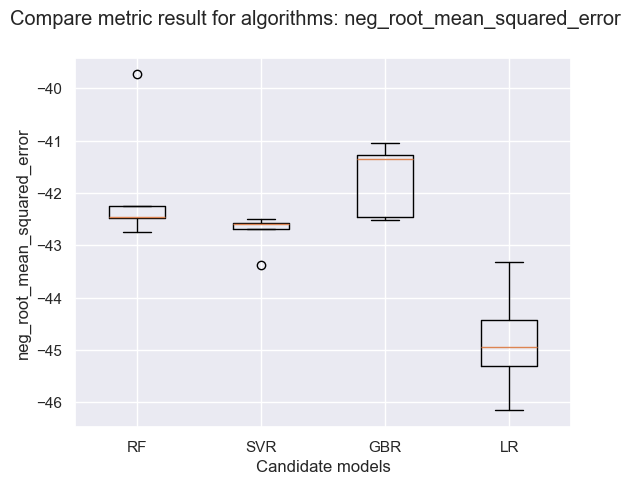

Evaluation metric:  r2
Model  RF
Model  SVR
Model  GBR
Model  LR
[('RF', 0.6274537981471127, 0.009221426033161359), ('SVR', 0.6137261045578033, 0.011597485850431412), ('GBR', 0.6328447637299247, 0.0084871487514744), ('LR', 0.5751654003897348, 0.0058042237096075444)]


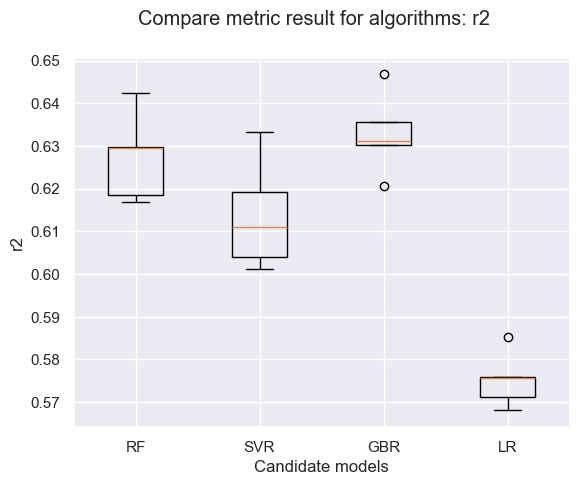

In [36]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

# Entreno Cross-validation

for scoring in error_metrics:
    
    results = [] # guarda los resultados de las métricas de evaluación
    names = []  # Nombre de cada algoritmo
    msg = []  # imprime el resumen del método de cross-validation
    
    print('Evaluation metric: ', scoring)
    
    for name, model in models:
        print('Model ', name)
        cross_validation = KFold(n_splits=num_folds, shuffle=True)
        cv_results = cross_val_score(model, X_train, y_train, cv=cross_validation, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        resume = (name, cv_results.mean(), cv_results.std())
        msg.append(resume)
    print(msg)

    # Compare results between algorithms
    fig = plt.figure()
    fig.suptitle('Compare metric result for algorithms: %s' %scoring)
    ax = fig.add_subplot(111)
    ax.set_xlabel('Candidate models')
    ax.set_ylabel('%s' %scoring)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

# *7. Ajuste de los hiperparámetros*.

Pasos para realizar el ajuste de los hiperparámetros:
* Especificar el modelo(s) a ajustar
* Especificar una métrica a optimizar
* Definir los rangos de los parámetros de búsqueda: *parámetros*
* Asignar un método de validación: *KFold*
* Buscar los hiperparámetros con los datos de validación: *X_val*

### Gradient Boosting

In [37]:
modelo = GradientBoostingRegressor()
scoring='r2'
params = {
    # Number of trees in random forest
    'n_estimators': [50, 100, 500],  # default=100
    # Maximum features
    'max_features': ['sqrt', 5, 10], # default='sqrt'
     # Maximum number of levels in tree
    'max_depth': [2, 5, None],  #deafult = None
}


# Search for the best combination of hyperparameters
cross_validation = KFold(n_splits=5, shuffle=False)
my_cv = cross_validation.split(X_val)
gsearch = GridSearchCV(estimator=modelo, param_grid=params, scoring=scoring, cv=my_cv)
gsearch.fit(X_val, y_val)

# Print best Result
print("Best result: %f using the following hyperparameters %s" % (gsearch.best_score_, gsearch.best_params_))
means = gsearch.cv_results_['mean_test_score']
stds = gsearch.cv_results_['std_test_score']
params = gsearch.cv_results_['params']

Best result: 0.643151 using the following hyperparameters {'max_depth': 5, 'max_features': 5, 'n_estimators': 50}


# 8. Evaluación Final del Modelo

In [38]:
# evaluate metrics on holdout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(max_depth=2, max_features=5, n_estimators=100)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_val)

print("Gradient Boosting Mean Squared Error: ", mean_squared_error(y_val, y_pred))
print("Gradient Boosting Mean Absolute Error: ", mean_absolute_error(y_val, y_pred))
print("Gradient Boosting r-squared: ", r2_score(y_val, y_pred))

Gradient Boosting Mean Squared Error:  1714.7507956176585
Gradient Boosting Mean Absolute Error:  30.079748703728747
Gradient Boosting r-squared:  0.6393723522014725


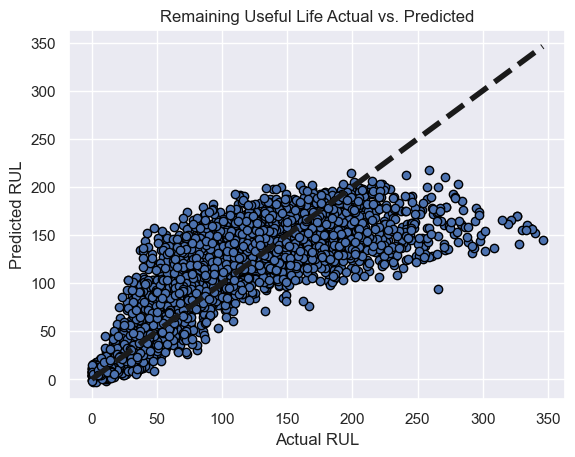

In [39]:
# plot actual vs predicted Remaining Useful Life for the best model
fig, ax = plt.subplots()
ax.scatter(y_val, y_pred, edgecolors=(0, 0, 0))
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=4)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title('Remaining Useful Life Actual vs. Predicted')
plt.show()

**¿Cómo podríamos mejorar los resultados?**

Opción: Trabajar solo con datos que tengan una Actual RUL < 150

## Vamos a comprobar con el dataset de Test
También tenemos que importar el archivo de RUL.

In [40]:
# load data
y_valid = pd.read_csv('Data/mantenimiento/RUL_FD001.txt', sep=" ", header=None)
y_valid

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN
...,...,...
95,137,NaN
96,82,NaN
97,59,NaN
98,117,NaN


In [41]:
y_valid.drop(1, axis=1, inplace=True)
y_valid

,0
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


In [42]:
X_valid = test.groupby('UnitNumber').last().reset_index()
X_valid

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,...,521.79,2388.06,8130.11,8.4024,0.03,393,2388,100.0,38.81,23.3552
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,...,521.74,2388.09,8126.90,8.4505,0.03,391,2388,100.0,38.81,23.2618
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,...,520.83,2388.14,8131.46,8.4119,0.03,395,2388,100.0,38.93,23.2740
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,...,521.88,2388.11,8133.64,8.4634,0.03,395,2388,100.0,38.58,23.2581
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,...,521.00,2388.15,8125.74,8.4362,0.03,394,2388,100.0,38.75,23.4117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,97,-0.0006,0.0003,100.0,518.67,642.30,1590.88,1397.94,14.62,...,522.30,2388.01,8148.24,8.4110,0.03,391,2388,100.0,38.96,23.4606
96,97,134,0.0013,-0.0001,100.0,518.67,642.59,1582.96,1410.92,14.62,...,521.58,2388.06,8155.48,8.4500,0.03,395,2388,100.0,38.61,23.2953
97,98,121,0.0017,0.0001,100.0,518.67,642.68,1599.51,1415.47,14.62,...,521.53,2388.09,8146.39,8.4235,0.03,394,2388,100.0,38.76,23.3608
98,99,97,0.0047,-0.0000,100.0,518.67,642.00,1585.03,1397.98,14.62,...,521.82,2388.02,8150.38,8.4003,0.03,391,2388,100.0,38.95,23.3595


In [43]:
X_valid = X_valid.drop(to_drop_1 + to_drop_2, axis = 1)

In [44]:
X_valid_s=scaler.fit_transform(X_valid)

In [45]:
print(X_valid_s.shape)
print(y_valid.shape)

(100, 13)
(100, 1)


In [46]:
X_s=scaler.fit_transform(X)

In [47]:
# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(max_depth=2, max_features=5, n_estimators=100)

gbr.fit(X_s, y)

y_val_pred = gbr.predict(X_valid_s)

print("Random Forest Mean Squared Error: ", mean_squared_error(y_valid, y_val_pred))
print("Random Forest Mean Absolute Error: ", mean_absolute_error(y_valid, y_val_pred))
print("Random Forest r-squared: ", r2_score(y_valid, y_val_pred))

Random Forest Mean Squared Error:  833.0112595919517
Random Forest Mean Absolute Error:  21.76210280886593
Random Forest r-squared:  0.5176177404524627


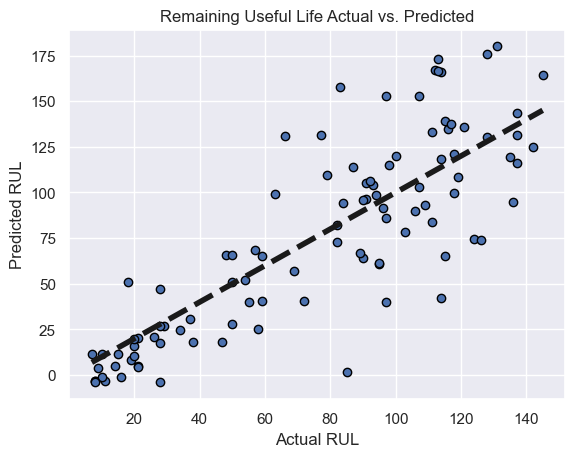

In [48]:
# plot actual vs predicted Remaining Useful Life for the best model (GBM)
fig, ax = plt.subplots()
ax.scatter(y_valid, y_val_pred, edgecolors=(0, 0, 0))
ax.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'k--', lw=4)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title('Remaining Useful Life Actual vs. Predicted')
plt.show()